In [77]:
%cd /home/raman/school/CMPT_459/project/cmpt-459-project

[Errno 2] No such file or directory: '/home/raman/school/CMPT_459/project/cmpt-459-project'
/Users/luannguyen/git/cmpt-459-project/notebooks


/Users/luannguyen/git/cmpt-459-project/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [78]:
from feature_selection.multi_feature_explorer import MultiFeatureExplorer
from utils.enums import Ticker, TimeFrame
from datetime import datetime
import matplotlib.pyplot as plt

In [79]:


explorer = MultiFeatureExplorer.from_bias_node(
    module_name='rsi',             
    ticker=[
        Ticker.ES,    # E-Mini S&P
        Ticker.NQ,    # E-Mini Nasdaq
        Ticker.YM,    # E-Mini Dow
        Ticker.RTY,   # E-Mini Russell 2000

        # # Energy
        # Ticker.CL,    # Crude Oil (WTI)
        # Ticker.HO,    # ULSD (Heating Oil)

        # # Metals
        # Ticker.GC,    # Gold
        # Ticker.HG,    # Copper
        # Ticker.SI,    # Silver
        # Ticker.PL,    # Platinum

        # # # Currencies (FX)
        # Ticker.EU,    # Euro Currency
        # Ticker.JY,    # Japanese Yen
        # Ticker.BP,    # British Pound
        # Ticker.CD,    # Canadian Dollar
        # Ticker.SF,    # Swiss Franc

        # # Agricultural (Food Grains)
        # Ticker.C,     # Corn
        # Ticker.S,     # Soybean
        # Ticker.W,     # Wheat (SRW)

        # # Meat
        # Ticker.GF,    # Feeder Cattle

        # # Fixed Income
        # Ticker.TY,    # 10Yr T.Note
        # Ticker.FV,    # 5Yr T.Note
        # Ticker.US,    # 30Yr T.Bond
        # Ticker.TU,     # 2Yr T.Note
    ],
    params={
        # 'span_fast': 16,
        # 'span_slow': 64,
        # 'span_ewsd': 32,
        # 'forecast_scalar': 1
        'lookback': 5,
        
    },
    start=datetime(2000, 1, 1),
    end=datetime(2024, 12, 31)
)



Extracting features from 'rsi'...


Running backtest features:   0%|          | 0/6323 [00:00<?, ?candles/s]/Users/luannguyen/git/cmpt-459-project/feature_extraction/ml_manager.py:121: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
/Users/luannguyen/git/cmpt-459-project/feature_extraction/ml_manager.py:121: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
Running backtest features:   0%|          | 0/6324 [00:00<?, ?candles/s]/Users/luannguyen/git/cmpt-459-project/f

Found 5 features from 'rsi':
  - atr_252_D_atr_252
  - atr_252_D_atr_pct_252
  - ewsd_252_D_ewsd_daily_pct
  - ewsd_252_D_ewsd_annual_pct
  - rsi_5_D_rsi_5

Creating explorers for all 5 features

Using extracted log_return as target (mean: 0.000230)
  ✓ Created explorer for 'atr_252_D_atr_252'
  ✓ Created explorer for 'atr_252_D_atr_pct_252'
  ✓ Created explorer for 'ewsd_252_D_ewsd_daily_pct'
  ✓ Created explorer for 'ewsd_252_D_ewsd_annual_pct'
  ✓ Created explorer for 'rsi_5_D_rsi_5'

Successfully created 5 FeatureExplorer instances


    feature_name  n_samples  feature_mean  feature_std  feature_min  \
0  rsi_5_D_rsi_5      20298     54.693327    20.102618          0.0   

   feature_max  target_mean  target_std  
0    98.552078      0.00023    0.013696  


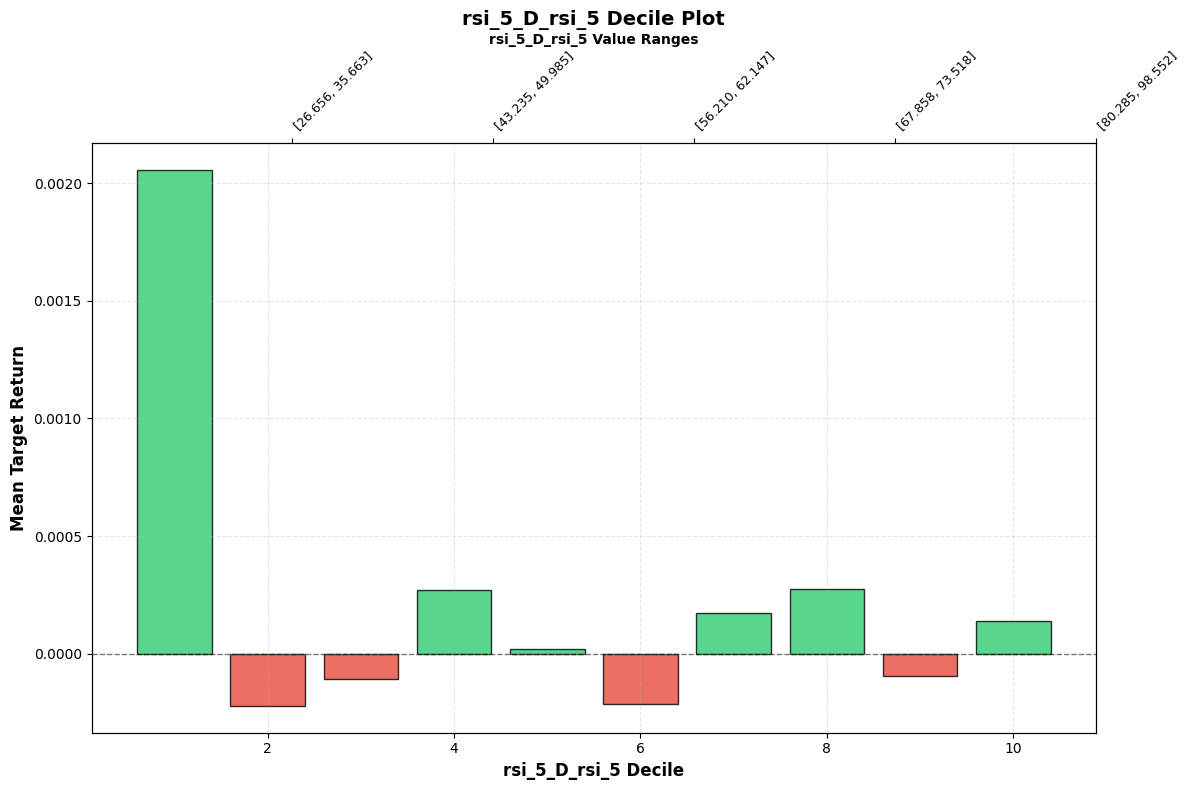

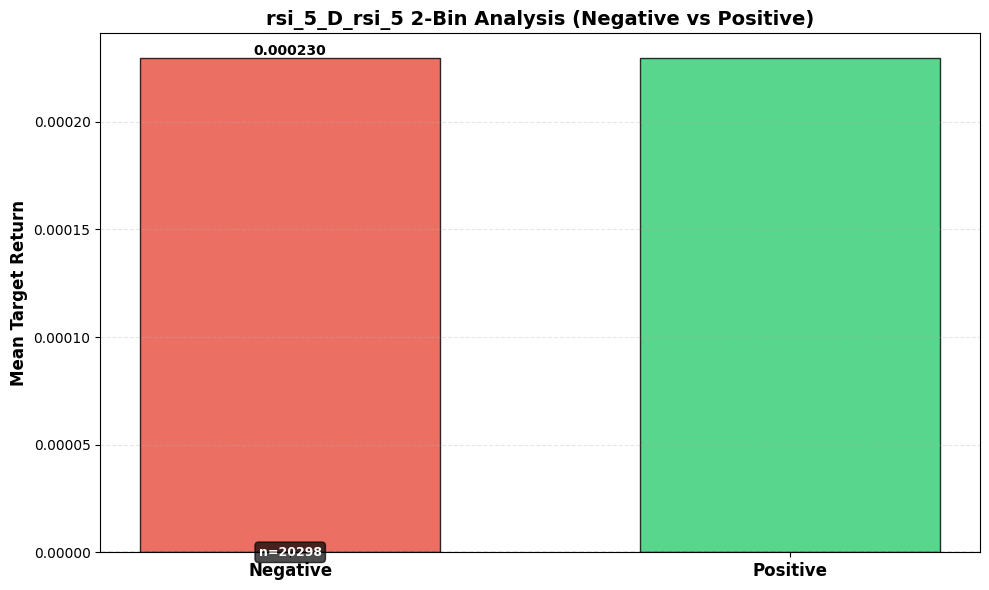

In [80]:

# Call methods directly - they apply to ALL features automatically!
figs = explorer.plot_feature_deciles(n_bins=10, target_col='log_return')
explorer.plot_2bin()

# Get summary of all results
summary_df = explorer.get_results_summary()
print(summary_df)

# Show all plots
plt.show()

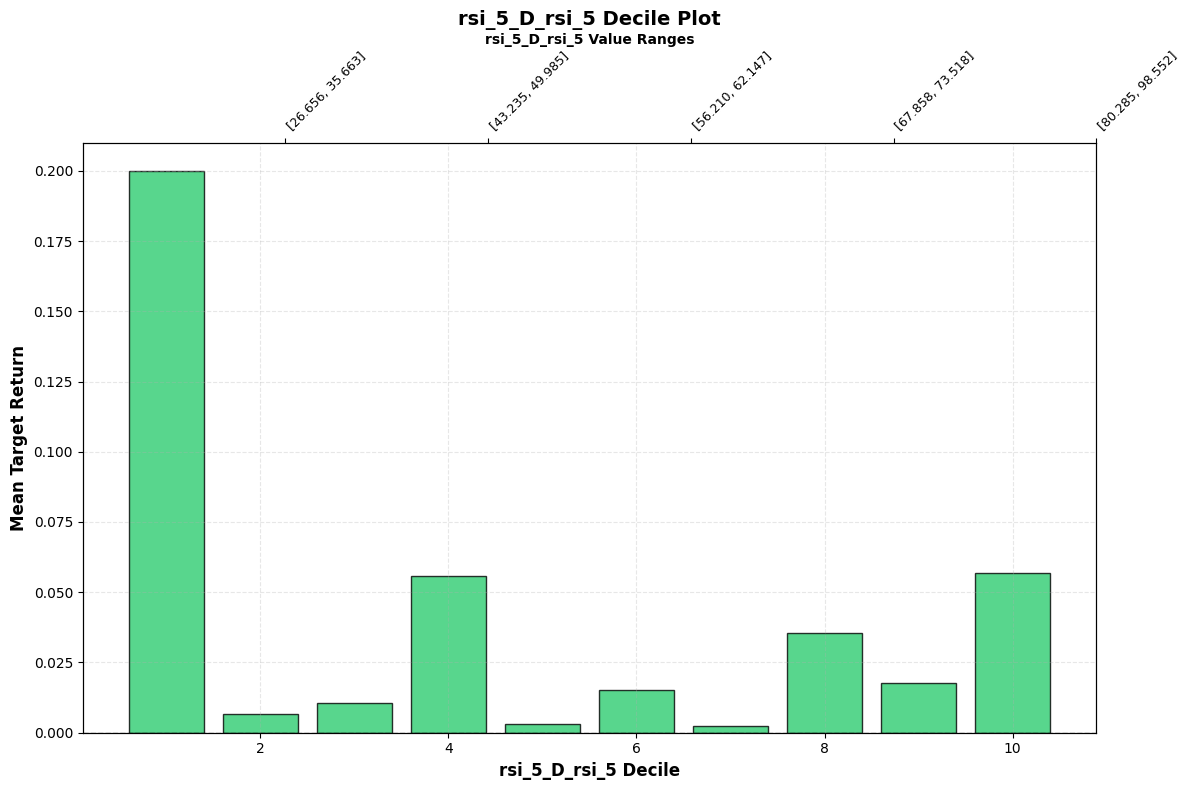

In [81]:

# Call methods directly - they apply to ALL features automatically!
figs = explorer.plot_feature_deciles(n_bins=10, target_col='log_return_ewsd')

# Show all plots
plt.show()

In [82]:
# TODO: no binning permutation test func

# results_df = explorer.binning_permutation_test(
#     n_bins=3,
#     min_samples_per_bin_pct=0.05,
#     nreps=1000,
#     alpha=0.1,
#     n_jobs=-1
# )

Computing rolling deciles for rsi_5_D_rsi_5...
Window size: 5475 days, Step size: 365 days

  Window 0: N/A to N/A
  Decile   Feature Range                  Mean Target     Count   
  -------- ------------------------------ --------------- --------
  1        [0.0000, 43.8513]              0.000438        3606    
  2        [43.8544, 65.3599]             -0.000193       3606    
  3        [65.3649, 98.3346]             -0.000020       3606    

  Window 1: N/A to N/A
  Decile   Feature Range                  Mean Target     Count   
  -------- ------------------------------ --------------- --------
  1        [0.0000, 44.3210]              0.000465        3688    
  2        [44.3251, 65.4990]             -0.000125       3688    
  3        [65.5039, 98.3346]             0.000073        3689    

  Window 2: N/A to N/A
  Decile   Feature Range                  Mean Target     Count   
  -------- ------------------------------ --------------- --------
  1        [0.0000, 44.7587]     

{'rsi_5_D_rsi_5': (<Figure size 1400x800 with 1 Axes>,
     decile    median      mean       std       min       max       p25  \
  0     1.0  0.000652  0.000651  0.000125  0.000381  0.000904  0.000581   
  1     2.0  0.000272  0.000233  0.000211 -0.000193  0.000759  0.000099   
  2     3.0  0.000273  0.000228  0.000113 -0.000084  0.000332  0.000183   
  
          p75  n_windows  
  0  0.000757         24  
  1  0.000366         25  
  2  0.000300         22  )}

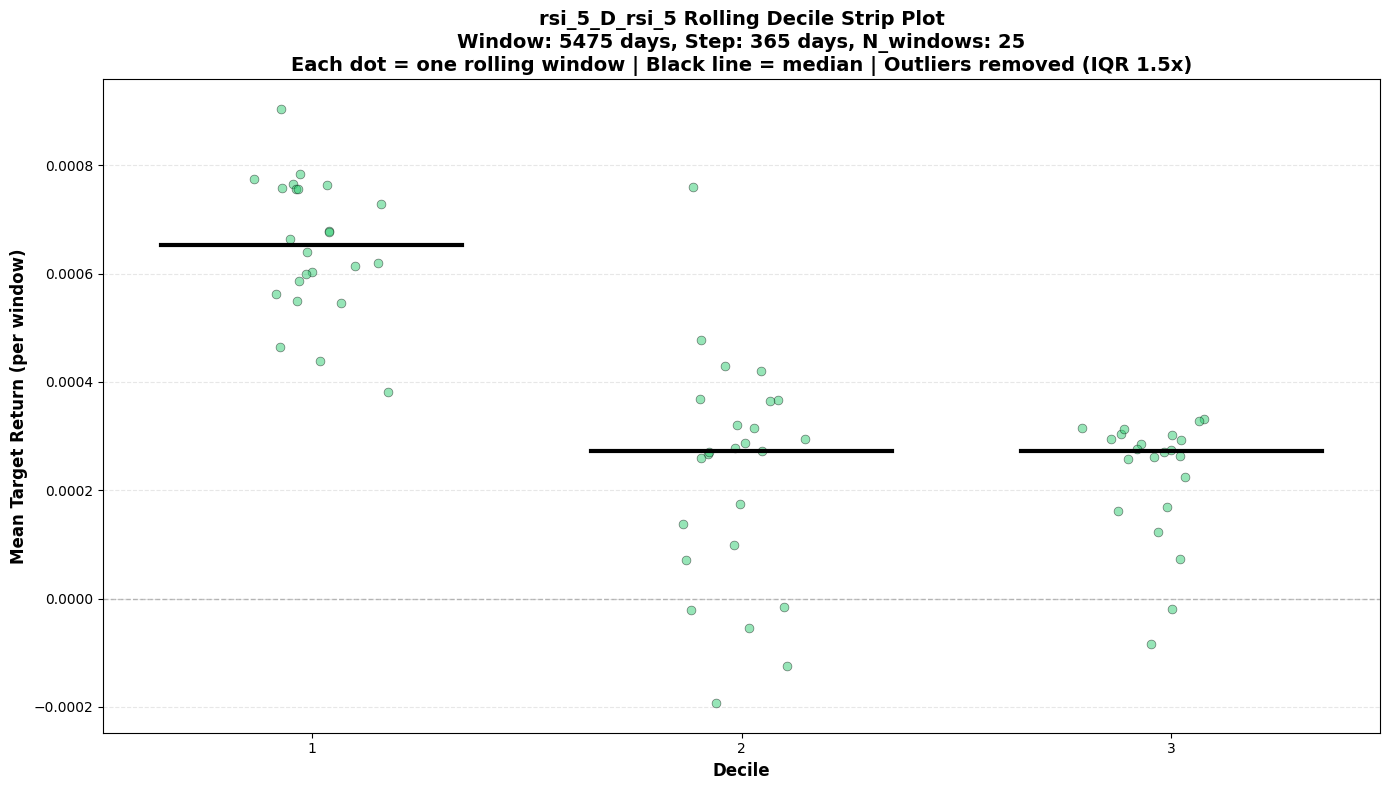

In [83]:
explorer.plot_rolling_decile_whiskers(
    window_size=5475,  # 1 year windows
    step_size=365,     # Roll forward quarterly
    n_bins=3
)


WALK-FORWARD BIN SELECTION FOR 1 FEATURES

=== Step 1/14 ===
  Train: 1995-01-01 to 2010-01-01 (n=7038)
  Test:  2010-01-01 to 2011-01-01 (n=759)
  ERROR: Unknown selection_metric: sharpe. Use 'sortino' or 'mean'

=== Step 2/14 ===
  Train: 1996-01-01 to 2011-01-01 (n=7797)
  Test:  2011-01-01 to 2012-01-01 (n=756)
  ERROR: Unknown selection_metric: sharpe. Use 'sortino' or 'mean'

=== Step 3/14 ===
  Train: 1996-12-31 to 2012-01-01 (n=8553)
  Test:  2012-01-01 to 2012-12-31 (n=756)
  ERROR: Unknown selection_metric: sharpe. Use 'sortino' or 'mean'

=== Step 4/14 ===
  Train: 1997-12-31 to 2012-12-31 (n=9309)
  Test:  2012-12-31 to 2013-12-31 (n=756)
  ERROR: Unknown selection_metric: sharpe. Use 'sortino' or 'mean'

=== Step 5/14 ===
  Train: 1998-12-31 to 2013-12-31 (n=10065)
  Test:  2013-12-31 to 2014-12-31 (n=756)
  ERROR: Unknown selection_metric: sharpe. Use 'sortino' or 'mean'

=== Step 6/14 ===
  Train: 1999-12-31 to 2014-12-31 (n=10821)
  Test:  2014-12-31 to 2015-12-31 (n=7

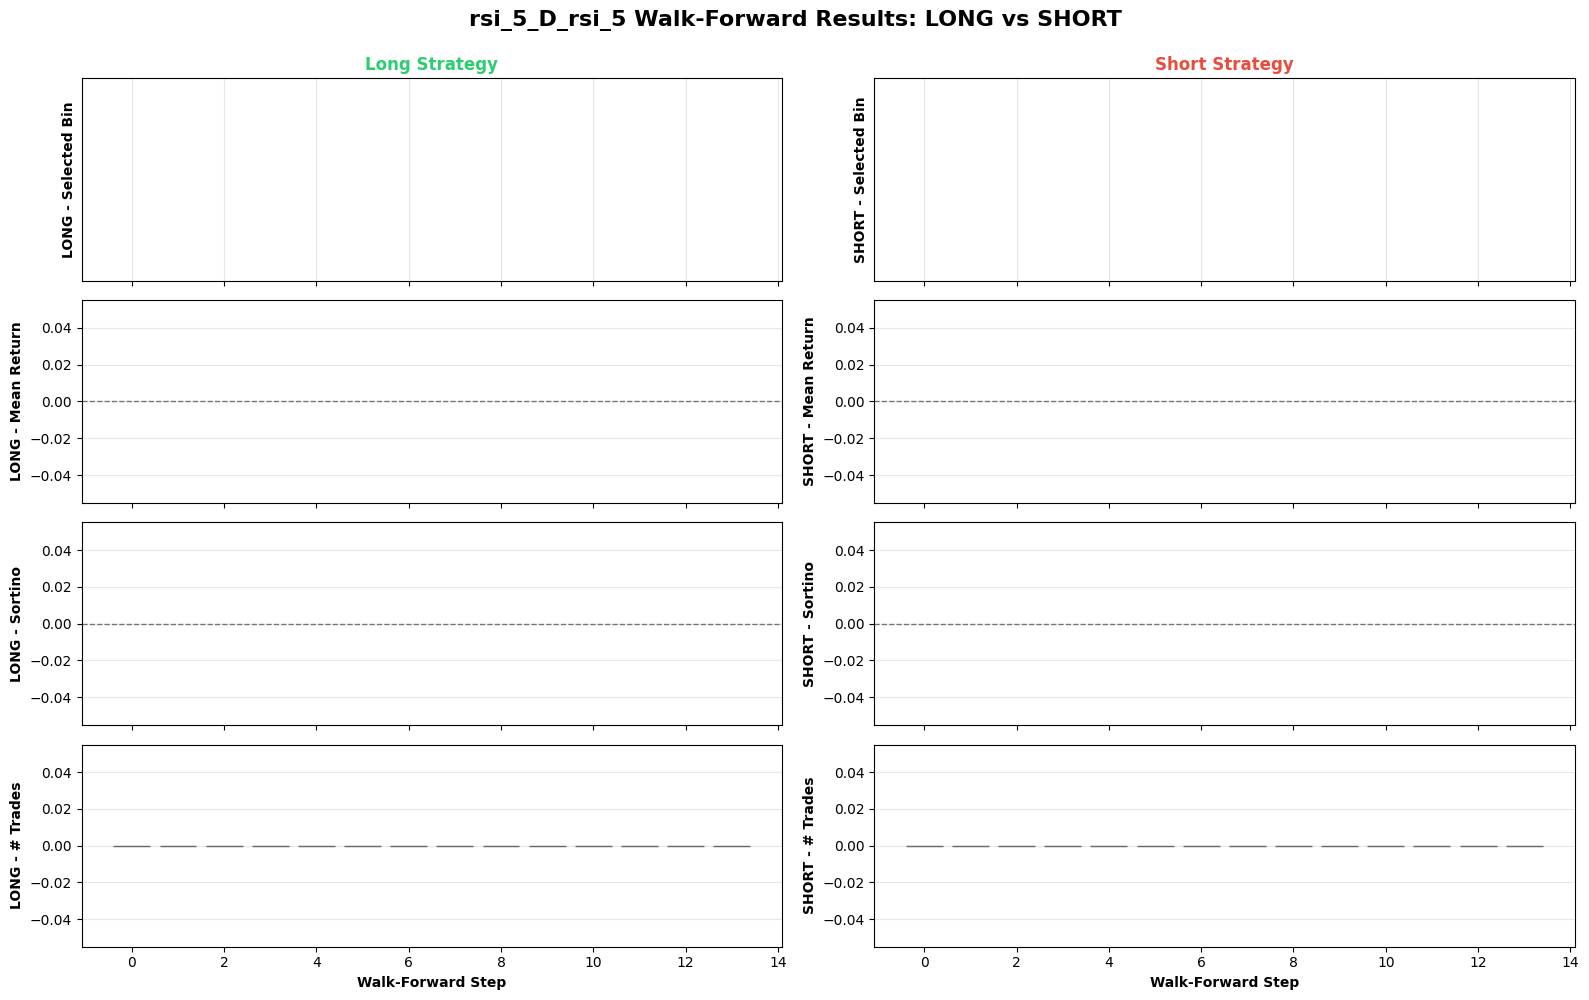

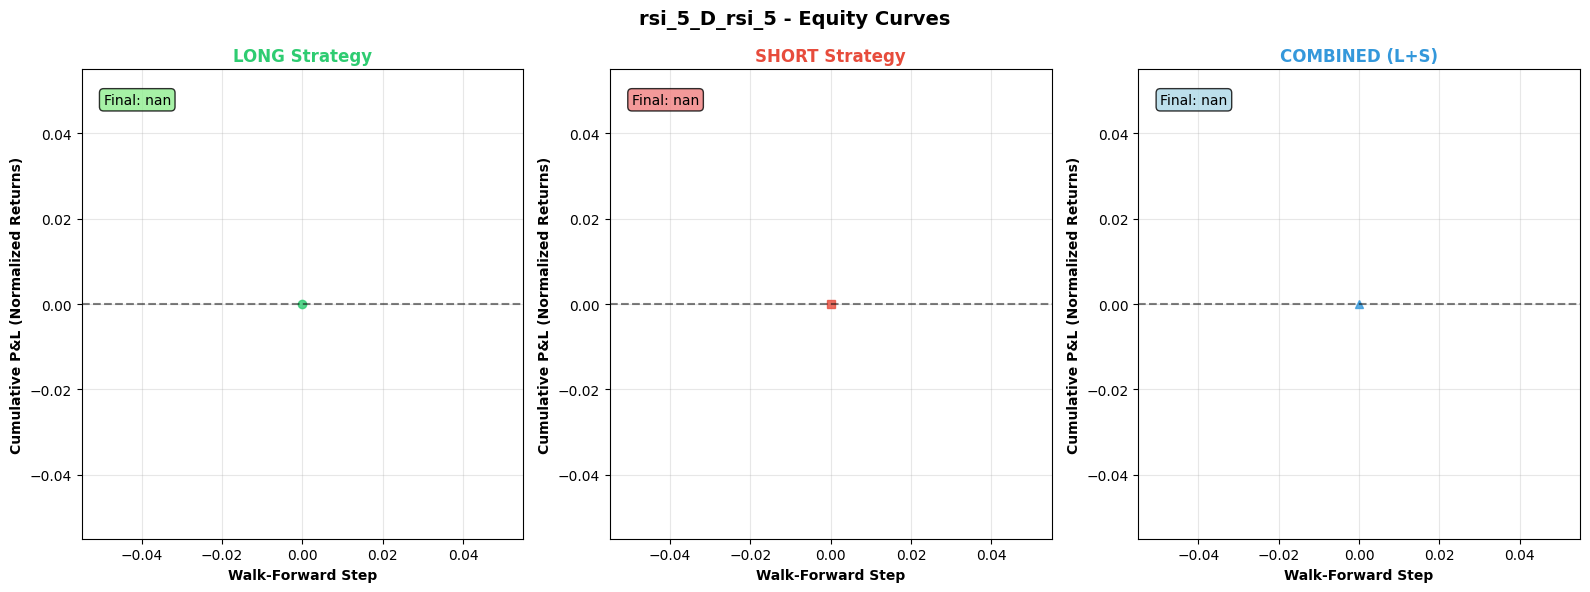

In [84]:
results_quantile = explorer.walkforward_bin_selection(
    train_start=datetime(1995, 1, 1),
    train_end=datetime(2010, 1, 1),  # 10 years training
    test_step=365,                    # 1 year test periods
    num_steps=14,                     # Test 2010-2024
    n_bins=3      # 3 bins
)

In [85]:
# TODO: no walkforward bin selection tree func

# results_tree = explorer.walkforward_bin_selection_tree(
#     train_start=datetime(1995, 1, 1),
#     train_end=datetime(2010, 1, 1),
#     test_step=365,
#     num_steps=14,
#     n_bins=3,
#     min_samples_leaf_pct=0.05
# )